# 10x Visium Breast Cancer — Exploration

This notebook downloads the **Human Breast Cancer (Block A Section 1)** Visium dataset from 10x Genomics, loads it with Scanpy, inspects the `AnnData` object, and generates spatial QC plots.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

SAMPLE_ID = "V1_Breast_Cancer_Block_A_Section_1"
DATA_ROOT = Path("../data/raw")
DATA_DIR = DATA_ROOT / SAMPLE_ID
FIG_DIR = Path("../outputs/figures")

sc.settings.figdir = str(FIG_DIR)
sc.set_figure_params(dpi=120, facecolor="white")

## 1. Download 10x Visium breast cancer dataset

Squidpy downloads files from the 10x Genomics CDN into `data/raw/`. The 10x matrix contains duplicate gene symbols; we fix that when loading in the next step.

In [17]:
import warnings

DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Squidpy loads the matrix internally to verify the download; suppress the
# expected duplicate-gene warning until we call var_names_make_unique() below.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Variable names are not unique")
    sq.datasets.visium(sample_id=SAMPLE_ID, base_dir=DATA_ROOT)

print(f"Data directory: {DATA_DIR.resolve()}")

Data directory: D:\WORKSPACE\Obsidian\Bao's windows\PhD\Biomedical-AI-Research\03-Projects\Project-01-Cancer-AI\github\Spatial-AI-for-Breast-Cancer-Tumor-Microenvironment-Mapping\data\raw\V1_Breast_Cancer_Block_A_Section_1


## 2. Load with Scanpy

`scanpy.read_visium` reads the filtered feature-barcode matrix and attaches spatial coordinates and H&E images.

In [21]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Variable names are not unique")
    adata = sq.read.visium(path=DATA_DIR)

adata.var_names_make_unique()
adata.obs["sample"] = SAMPLE_ID
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

## 3. Inspect AnnData object

In [22]:
print("obs (spots):")
display(adata.obs.head())

print("\nvar (genes):")
display(adata.var.head())

print("\nobsm keys:", list(adata.obsm.keys()))
print("uns keys:", list(adata.uns.keys()))

library_id = list(adata.uns["spatial"].keys())[0]
print(f"\nspatial library: {library_id}")
print("spatial metadata keys:", list(adata.uns["spatial"][library_id].keys()))

obs (spots):


,in_tissue,array_row,array_col,sample
AAACAAGTATCTCCCA-1,1,50,102,V1_Breast_Cancer_Block_A_Section_1
AAACACCAATAACTGC-1,1,59,19,V1_Breast_Cancer_Block_A_Section_1
AAACAGAGCGACTCCT-1,1,14,94,V1_Breast_Cancer_Block_A_Section_1
AAACAGGGTCTATATT-1,1,47,13,V1_Breast_Cancer_Block_A_Section_1
AAACAGTGTTCCTGGG-1,1,73,43,V1_Breast_Cancer_Block_A_Section_1



var (genes):


,gene_ids,feature_types,genome
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38
AL627309.1,ENSG00000238009,Gene Expression,GRCh38
AL627309.3,ENSG00000239945,Gene Expression,GRCh38



obsm keys: ['spatial']
uns keys: ['spatial']

spatial library: V1_Breast_Cancer_Block_A_Section_1
spatial metadata keys: ['metadata', 'images', 'scalefactors']


## 4–6. Spatial plots

Compute per-spot QC metrics, then plot the H&E tissue image, total counts, and genes detected per spot.

In [23]:
sc.pp.calculate_qc_metrics(adata, inplace=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

library_id = list(adata.uns["spatial"].keys())[0]

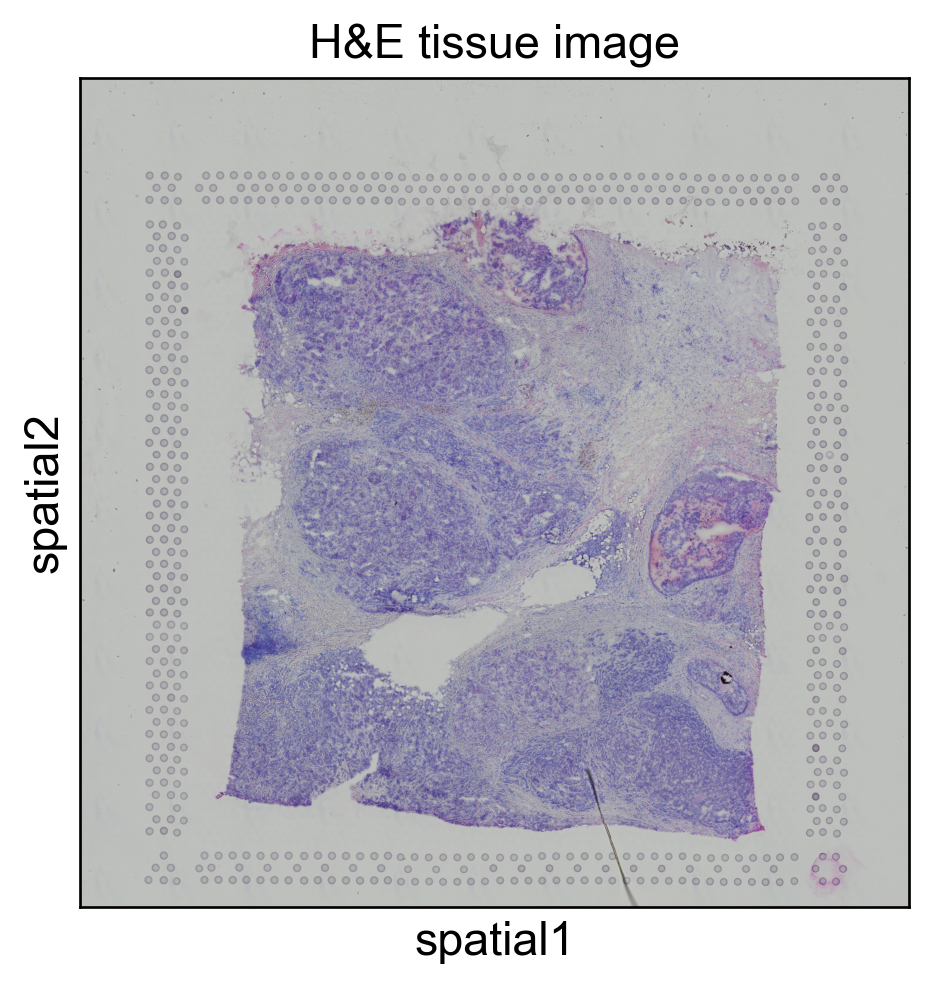

In [25]:
# Tissue image (H&E)
sq.pl.spatial_scatter(adata, library_id=library_id, color=None, title="H&E tissue image")

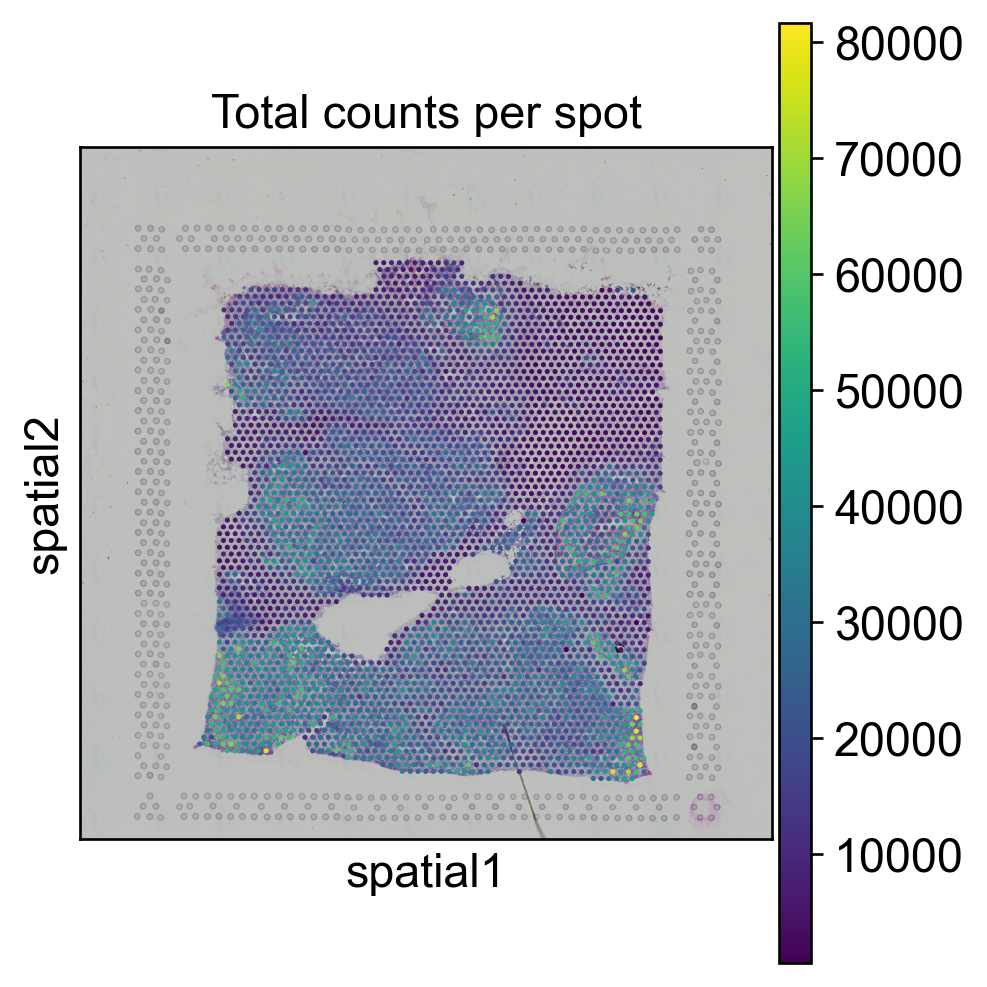

In [27]:
# Total counts per spot
sq.pl.spatial_scatter(adata, library_id=library_id, color="total_counts", title="Total counts per spot")

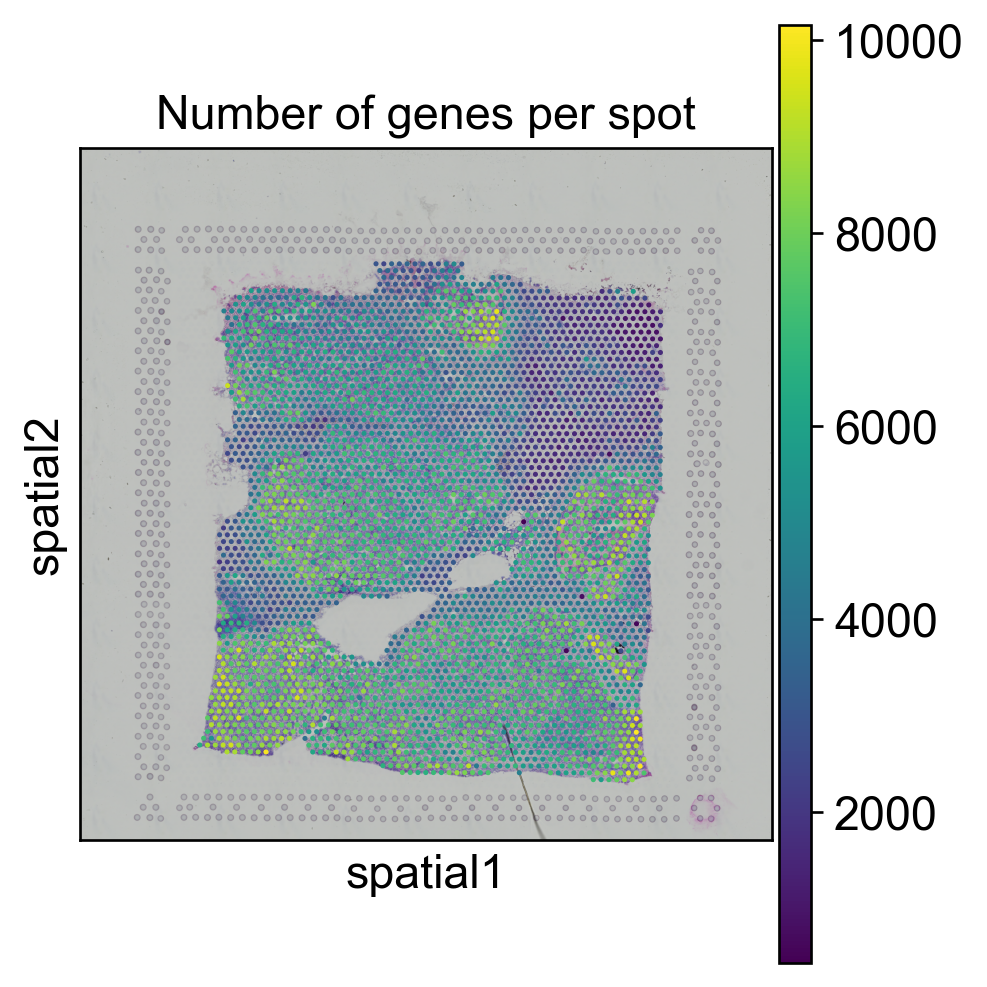

In [29]:
# Number of genes per spot
sq.pl.spatial_scatter(adata, library_id=library_id, color="n_genes_by_counts", title="Number of genes per spot")